In [1]:
import sys, os
from pathlib import Path
from pprint import pprint
from copy import deepcopy

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yaml
from tqdm import tqdm

BASE_DIR = Path.cwd().resolve().parent.parent
SCRIPT_DIR = Path.cwd().resolve()
sys.path.append(str(BASE_DIR))
group_name = 'fidelity_exp'
EXP_DIR = SCRIPT_DIR / group_name
EXP_CFG_DIR = EXP_DIR / 'configs'
RES_DIR = EXP_DIR / 'results'
CFG_DIR = SCRIPT_DIR / 'configs'


from data.nyc_taxi_dataset import NYCTaxiDataset
from experiment_board.anomaly_detection_journal_exps.simulated_experiment_classes import Experiment, hp_study, SNN_LOGN_GTVObjective, get_data, calculate_metrics

from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from src.models.tucker_decomp.hosvd import hosvd
from src.metrics.estimate_rank import estimate_tucker_rank

from src.metrics.metric_tracker import MetricTracker
from src.multilinear_ops.matricize import matricize
from src.multilinear_ops.tensorize import tensorize
from src.multilinear_ops.merge_tucker import merge_tucker

In [2]:
nycd = NYCTaxiDataset()

G = nycd.G_nyc
Gt = nycd.Gt
Y = nycd.dropoffs
print(Y.shape)
print("Spatial Graph")
print("Nodes: ", len(G.nodes()))
print("Edges: ", len(G.edges()))
print("Temporal Graph")
print("Nodes: ", len(Gt.nodes()))
print("Edges: ", len(Gt.edges()))

(81, 53, 7, 24)
Spatial Graph
Nodes:  81
Edges:  208
Temporal Graph
Nodes:  24
Edges:  23


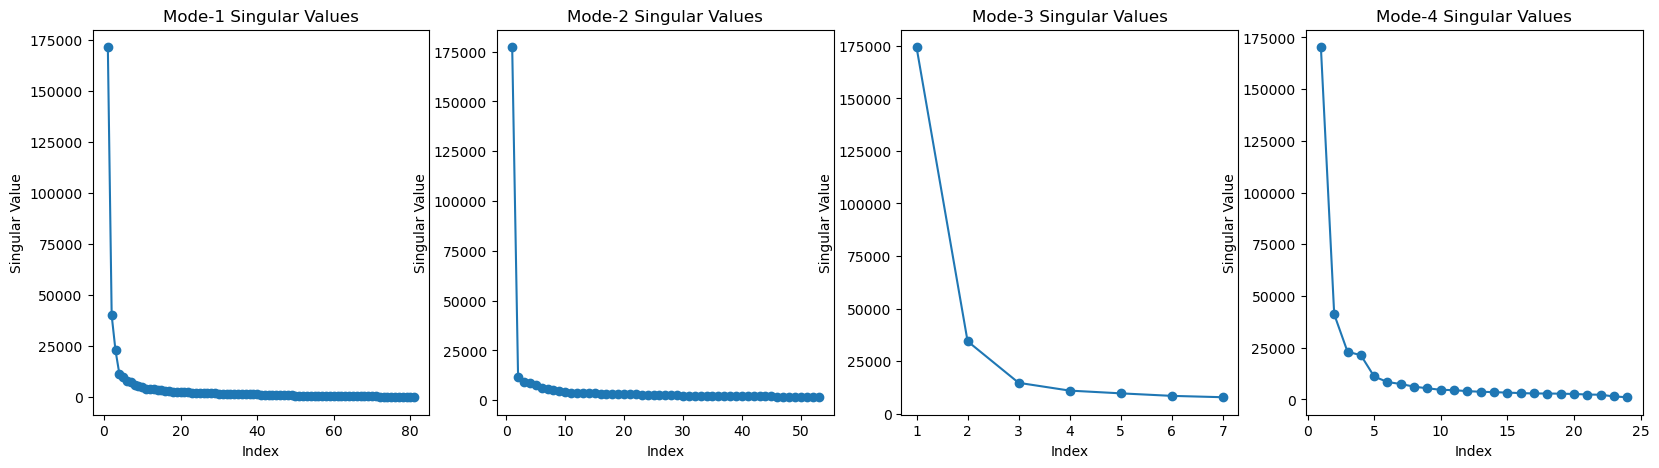

In [3]:
hosvd_result = hosvd(Y, modes=[1,2,3,4])
# estimate_tucker_rank(Y)
hosvd_result.keys()
fig, axes = plt.subplots(nrows=1,ncols=4, figsize=(20,5))

axs = axes.flatten()
for i in range(4):
    svals = (hosvd_result['svals'][i]).cpu().numpy()
    axs[i].plot(np.arange(1, len(svals)+1), svals, marker='o', linestyle='-')
    axs[i].set_title(f'Mode-{i+1} Singular Values')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Singular Value')

In [6]:
estimate_tucker_rank(Y, method='GCV')

{'estimated_ranks': [80, 53, 7, 24],
 'num_param': 712400.0,
 'r2_value': 0.9999999966472435,
 'residual_energy': 107.80846405029297}

In [6]:
results = estimate_tucker_rank(Y, method='core_thresholding', r2_thr=0.99)
pprint(results)

ranks = results['estimated_ranks']
C_D = np.prod(results['estimated_ranks'])
D =  np.prod(Y.shape)
P = results['num_param']
E = results['residual_energy']
var_est_1 = E / D
var_est_2 = E / (D - P)
var_est_3 = E / (D - C_D)
print(f"Estimated variance (1): {var_est_1}")
print(f"Estimated variance (2): {var_est_2}")
print(f"Estimated variance (3): {var_est_3}")

merge
t_hosvd = hosvd(Y, modes=[1,2,3,4], device='cuda:2')
t_X = merge_tucker(t_hosvd['core'].cpu().numpy(), 
                    [u[:,:ranks[i]].cpu().numpy() for i, u in enumerate(t_hosvd['factors'])],
                    dims=[0,1,2,3],)
S = Y - t_X
median_S = np.median(S.ravel())
Q1 = np.quantile(S.ravel(), 0.25)
Q3 = np.quantile(S.ravel(), 0.75)
IQR = Q3 - Q1
print(f"Interquartile Range (IQR): {IQR}")
print(f"Q1: {Q1}, Q3: {Q3}")
non_outliers = S[(S >= Q1 - 1.5 * IQR) & (S <= Q3 + 1.5 * IQR)]
print(f"Median of S: {median_S}")
print(f"Number of non-outliers: {len(non_outliers)}")
variance_est_3 = np.var(non_outliers)
print(f"Estimated variance of with non-outliers: {variance_est_3}")
variance_est_4 = variance_est_3* D / (D - P)
variance_est_5 = variance_est_3* D / (D - C_D)
print(f"Estimated variance with non-outliers D/(D-P) corrected: {variance_est_4}")
print(f"Estimated variance with non-outliers D/(D-C_D) corrected: {variance_est_5}")

plt.hist(S.ravel(), bins=100, density=True)
plt.axvline(median_S, color='red', linestyle='dashed', linewidth=1, label='Median')
plt.axvline(Q1, color='green', linestyle='dashed', linewidth=1, label='Q1')
plt.axvline(Q3, color='blue', linestyle='dashed', linewidth=1, label='Q3')
plt.axvline(Q1 - 1.5 * IQR, color='purple', linestyle='dashed', linewidth=1, label='LB(Q1 - 1.5 * IQR)')
plt.axvline(Q3 + 1.5 * IQR, color='orange', linestyle='dashed', linewidth=1, label='UB(Q3 + 1.5 * IQR)')
plt.legend()
plt.title('Histogram of S')

{'estimated_ranks': [13, 15, 7, 11],
 'num_param': 16612.0,
 'r2_value': 0.9900192128726562,
 'residual_energy': 320933928.7926216}
Estimated variance (1): 444.9850931092443
Estimated variance (2): 455.4761042852259
Estimated variance (3): 454.44610418816757


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 81 is different from 13)